# Telecom Customer Churn Prediction using PySpark and XGBoost

**Author:** Suresh Sampath Manawadu  
**Programme:** MSc Data Science – Coventry University  

## Objective
Develop a scalable machine learning pipeline to predict telecom customer churn and compare Random Forest and XGBoost models.

## Workflow
EDA → Preprocessing → Feature Engineering → Modeling → Evaluation → Explainability


In [1]:
# Colab environment setup
!apt-get -qq update
!apt-get -qq install -y openjdk-11-jdk-headless > /dev/null
!pip -q install pyspark xgboost scikit-learn pandas matplotlib seaborn shap

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, trim, when, upper, sum as _sum

from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

import xgboost as xgb
import shap


In [3]:
# Start Spark

spark = SparkSession.builder.appName("TelcoChurn").getOrCreate()
spark.sparkContext.setLogLevel("WARN")

In [4]:
# Upload and load datasets

from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df_raw = spark.read.csv(filename, header=True, inferSchema=True)

print("Rows:", df_raw.count())
df_raw.printSchema()
df_raw.show(5, truncate=False)

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
Rows: 7043
root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: string (nullable = true)
 |-- Churn: string (null

In [5]:
# Define Feature Groups

id_col = "customerID"
target_col = "Churn"

numeric_cols_eda = ["tenure", "MonthlyCharges", "TotalCharges"]

numeric_cols_model = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]

yesno_cols = [
    "Partner", "Dependents", "PhoneService", "MultipleLines",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "PaperlessBilling"
]

multi_cat_cols = ["gender", "InternetService", "Contract", "PaymentMethod"]

categorical_cols = yesno_cols + multi_cat_cols

customerID           object
gender               object
SeniorCitizen         int32
Partner              object
Dependents           object
tenure                int32
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


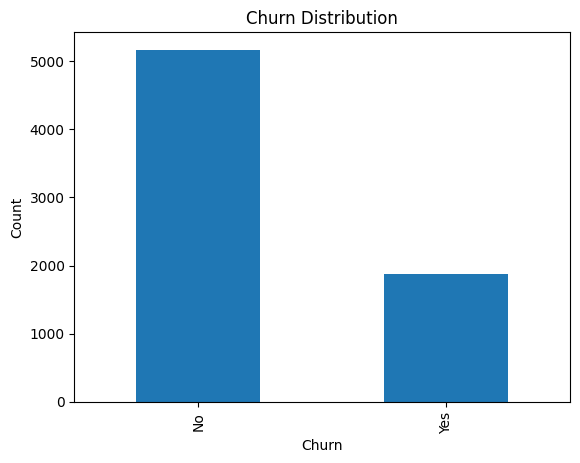

In [6]:
# Exploratory Data Analysis for Raw Data

df_pd_raw = df_raw.toPandas()

print(df_pd_raw.dtypes)

# Target distribution
df_pd_raw["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [7]:
# Check Missing values before cleaning

df_raw.select([
    _sum((col(c).isNull() | (trim(col(c)) == "")).cast("int")).alias(f"{c}_missing")
    for c in numeric_cols_eda
]).show()

+--------------+----------------------+--------------------+
|tenure_missing|MonthlyCharges_missing|TotalCharges_missing|
+--------------+----------------------+--------------------+
|             0|                     0|                  11|
+--------------+----------------------+--------------------+



In [8]:
# Data Preprocessing in Spark

df = df_raw.withColumn("TotalCharges", trim(col("TotalCharges")))

df = df.withColumn(
    "TotalCharges",
    when((col("TotalCharges") == "") | col("TotalCharges").isNull(), None)
    .otherwise(col("TotalCharges").cast("double"))
)

df = df.filter(col("tenure") > 0)
df = df.dropna(subset=["TotalCharges", "MonthlyCharges", "tenure", "Churn"])

In [9]:
# Validate Clean numerical fields

df.select([
    _sum((col(c).isNull()).cast("int")).alias(f"{c}_nulls")
    for c in ["tenure", "MonthlyCharges", "TotalCharges"]
]).show()

df.select("tenure", "MonthlyCharges", "TotalCharges").describe().show()

+------------+--------------------+------------------+
|tenure_nulls|MonthlyCharges_nulls|TotalCharges_nulls|
+------------+--------------------+------------------+
|           0|                   0|                 0|
+------------+--------------------+------------------+

+-------+------------------+------------------+------------------+
|summary|            tenure|    MonthlyCharges|      TotalCharges|
+-------+------------------+------------------+------------------+
|  count|              7032|              7032|              7032|
|   mean|32.421786120591584| 64.79820819112632|2283.3004408418697|
| stddev|24.545259709263245|30.085973884049825| 2266.771361883145|
|    min|                 1|             18.25|              18.8|
|    max|                72|            118.75|            8684.8|
+-------+------------------+------------------+------------------+



In [10]:
# Check Data types
df_pd = df.toPandas()

print(df_pd.dtypes)

customerID           object
gender               object
SeniorCitizen         int32
Partner              object
Dependents           object
tenure                int32
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


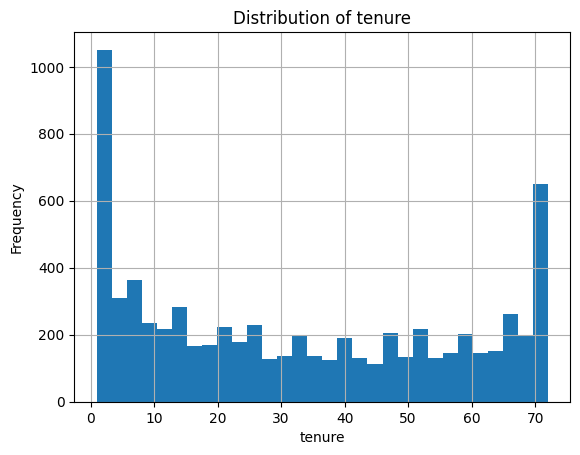

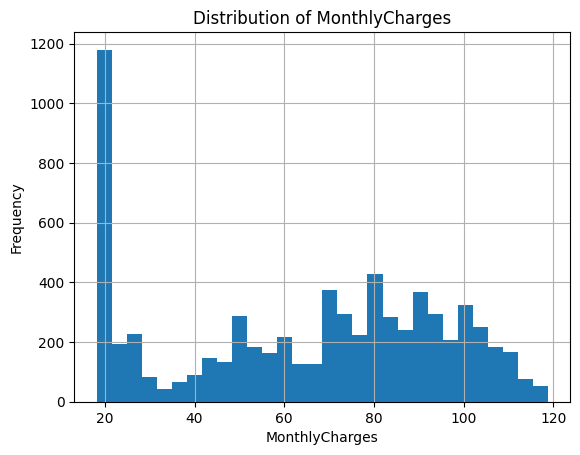

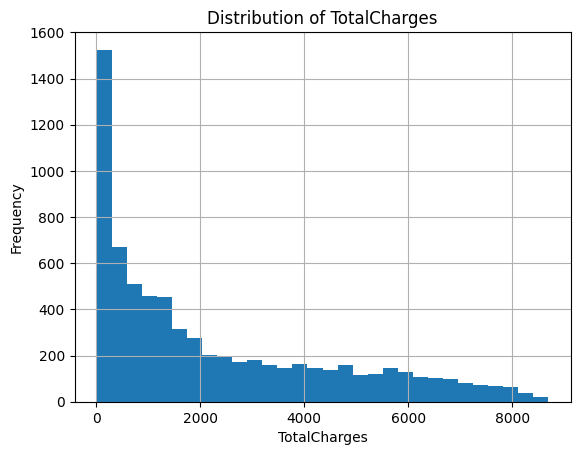

In [11]:
# Numerical Distribution

for col_name in numeric_cols_eda:
    df_pd[col_name].hist(bins=30)
    plt.title(f"Distribution of {col_name}")
    plt.xlabel(col_name)
    plt.ylabel("Frequency")
    plt.show()

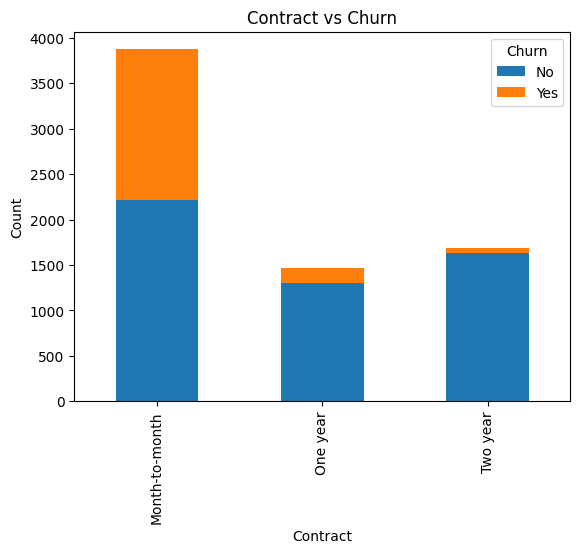

In [12]:
# Contract Vs Churn

pd.crosstab(df_pd["Contract"], df_pd["Churn"]).plot(kind="bar", stacked=True)
plt.title("Contract vs Churn")
plt.xlabel("Contract")
plt.ylabel("Count")
plt.show()

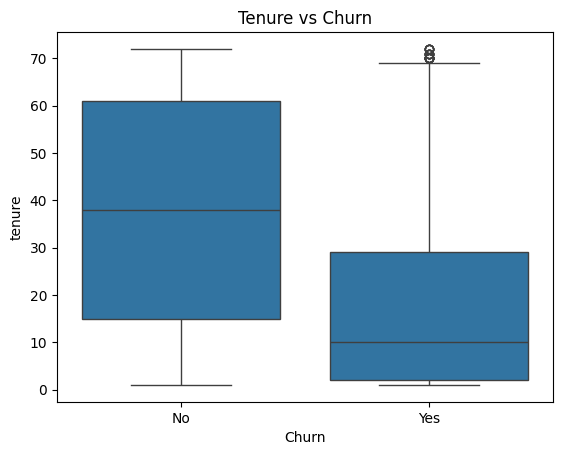

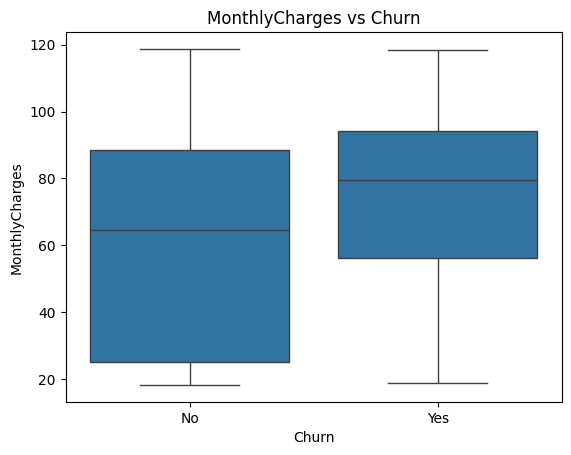

In [13]:
# Boxplots

sns.boxplot(x="Churn", y="tenure", data=df_pd)
plt.title("Tenure vs Churn")
plt.show()

sns.boxplot(x="Churn", y="MonthlyCharges", data=df_pd)
plt.title("MonthlyCharges vs Churn")
plt.show()

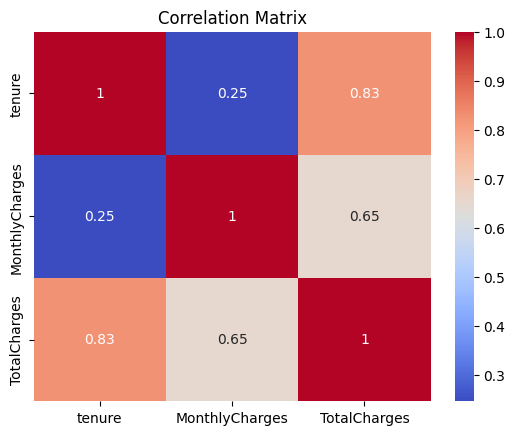

In [14]:
# Correlation Heatmap

corr = df_pd[numeric_cols_eda].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [15]:
# Label Creation

df = df.withColumn("Churn_clean", upper(trim(col("Churn"))))
df = df.filter(col("Churn_clean").isin("YES", "NO"))

df = df.withColumn(
    "label",
    when(col("Churn_clean") == "YES", 1.0).otherwise(0.0)
)

df.groupBy("label").count().orderBy("label").show()

+-----+-----+
|label|count|
+-----+-----+
|  0.0| 5163|
|  1.0| 1869|
+-----+-----+



In [16]:
# Feature Enginnering Pipeline

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_cols
]

encoder = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in categorical_cols],
    outputCols=[f"{c}_oh" for c in categorical_cols],
    handleInvalid="keep"
)

assembler = VectorAssembler(
    inputCols=[f"{c}_oh" for c in categorical_cols] + numeric_cols_model,
    outputCol="features"
)

pipeline = Pipeline(stages=indexers + [encoder, assembler])

pipe_model = pipeline.fit(df)
data = pipe_model.transform(df).select(id_col, "label", "features")

In [17]:
# Extract feature names for model interpretation and SHAP

def get_feature_names_from_metadata(df_spark, features_col="features"):
    meta = df_spark.schema[features_col].metadata
    attrs = []
    for group in ["binary", "numeric", "nominal"]:
        if "ml_attr" in meta and "attrs" in meta["ml_attr"] and group in meta["ml_attr"]["attrs"]:
            attrs.extend(meta["ml_attr"]["attrs"][group])
    attrs = sorted(attrs, key=lambda x: x["idx"])
    return [x["name"] for x in attrs]

feature_names = get_feature_names_from_metadata(data, "features")
print("Number of feature names:", len(feature_names))
print(feature_names[:10])

Number of feature names: 60
['Partner_oh_No', 'Partner_oh_Yes', 'Partner_oh___unknown', 'Dependents_oh_No', 'Dependents_oh_Yes', 'Dependents_oh___unknown', 'PhoneService_oh_Yes', 'PhoneService_oh_No', 'PhoneService_oh___unknown', 'MultipleLines_oh_No']


In [18]:
# Train/Test Split

train, test = data.randomSplit([0.7, 0.3], seed=42)

print("Train rows:", train.count())
print("Test rows :", test.count())

train.groupBy("label").count().orderBy("label").show()
test.groupBy("label").count().orderBy("label").show()

Train rows: 5028
Test rows : 2004
+-----+-----+
|label|count|
+-----+-----+
|  0.0| 3692|
|  1.0| 1336|
+-----+-----+

+-----+-----+
|label|count|
+-----+-----+
|  0.0| 1471|
|  1.0|  533|
+-----+-----+



In [19]:
# Random Forest Model

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=200,
    maxDepth=10,
    seed=42
)

rf_model = rf.fit(train)
rf_pred = rf_model.transform(test)

In [20]:
# Random Forest Evaluation

def eval_spark_classifier(pred_df, prediction_col="prediction"):
    acc = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol=prediction_col, metricName="accuracy"
    ).evaluate(pred_df)

    f1 = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol=prediction_col, metricName="f1"
    ).evaluate(pred_df)

    roc = BinaryClassificationEvaluator(
        labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
    ).evaluate(pred_df)

    return acc, f1, roc

rf_acc, rf_f1, rf_roc = eval_spark_classifier(rf_pred)

print("Random Forest")
print("Accuracy:", rf_acc)
print("F1      :", rf_f1)
print("ROC AUC :", rf_roc)

Random Forest
Accuracy: 0.8053892215568862
F1      : 0.7949157019731824
ROC AUC : 0.8556080470076326


In [21]:
# Random Forest Feature Importance

rf_importances = rf_model.featureImportances.toArray()

fi_rf = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

fi_rf.head(15)

,Feature,Importance
56,tenure,0.147890
58,TotalCharges,0.112259
47,Contract_oh_Month-to-month,0.095155
57,MonthlyCharges,0.069411
13,OnlineSecurity_oh_No,0.049768
51,PaymentMethod_oh_Electronic check,0.044287
43,InternetService_oh_Fiber optic,0.043892
48,Contract_oh_Two year,0.036656
25,TechSupport_oh_No,0.036337
44,InternetService_oh_DSL,0.021789


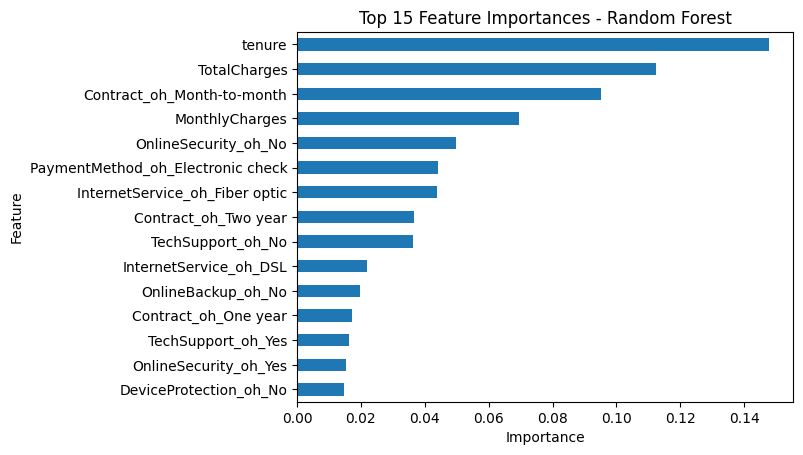

In [22]:
# Plot Random Forest Feature Importance

fi_rf.head(15).sort_values(by="Importance").plot(
    kind="barh", x="Feature", y="Importance", legend=False
)
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [23]:
# Prepare Pandas Metrices for XGBOOST
train_pd = train.toPandas()
test_pd = test.toPandas()

X_train = np.vstack(train_pd["features"].apply(lambda x: x.toArray()))
y_train = train_pd["label"].values

X_test = np.vstack(test_pd["features"].apply(lambda x: x.toArray()))
y_test = test_pd["label"].values

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 2.7634730538922154


In [24]:
# XGBOOST Gridserach

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [200, 300],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_df, y_train)

print("Best Params:", grid_search.best_params_)
print("Best ROC (CV):", grid_search.best_score_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best ROC (CV): 0.8392754237659084


In [25]:
# Find best XGBOOST model and Threshold

best_xgb = grid_search.best_estimator_

y_prob_xgb = best_xgb.predict_proba(X_test_df)[:, 1]

threshold_results = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    y_pred_t = (y_prob_xgb > t).astype(int)
    threshold_results.append({
        "Threshold": t,
        "F1": f1_score(y_test, y_pred_t)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,F1
0,0.3,0.596341
1,0.4,0.628533
2,0.5,0.648889
3,0.6,0.648101
4,0.7,0.627335
5,0.8,0.486826


In [26]:
# Final XGBoost evaluation at best threshold

best_threshold = threshold_df.sort_values(by="F1", ascending=False).iloc[0]["Threshold"]
print("Best threshold:", best_threshold)

y_pred_xgb = (y_prob_xgb > best_threshold).astype(int)

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost")
print("Accuracy:", xgb_acc)
print("F1      :", xgb_f1)
print("ROC AUC :", xgb_roc)

Best threshold: 0.5
XGBoost
Accuracy: 0.7634730538922155
F1      : 0.6488888888888888
ROC AUC : 0.856432619129308


In [27]:
# Model Comparison

results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_acc, xgb_acc],
    "F1": [rf_f1, xgb_f1],
    "ROC AUC": [rf_roc, xgb_roc]
})

results

,Model,Accuracy,F1,ROC AUC
0,Random Forest,0.805389,0.794916,0.855608
1,XGBoost,0.763473,0.648889,0.856433


 94%|=================== | 1877/2004 [00:13<00:00]       

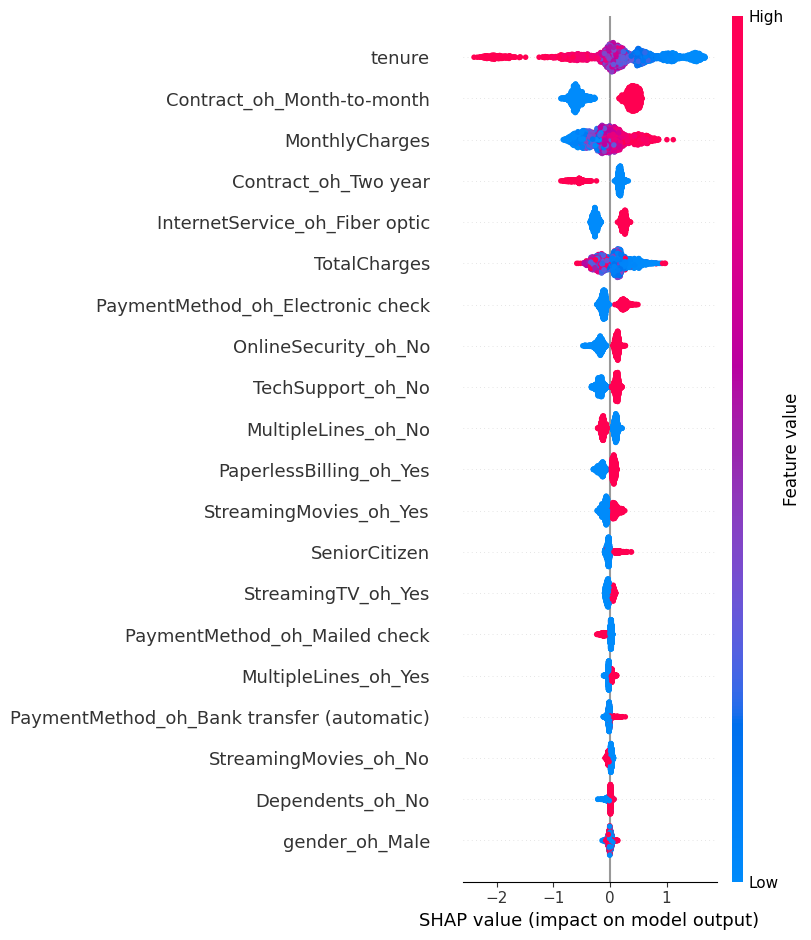

In [28]:
# SHAP with Generic Names

explainer = shap.Explainer(best_xgb, X_train_df)
shap_values = explainer(X_test_df)

shap.summary_plot(shap_values, X_test_df)

In [ ]:
# SHAP bar plot

shap.summary_plot(shap_values, X_test_df, plot_type="bar")

## Conclusion

This notebook developed a scalable telecom churn prediction workflow using PySpark for preprocessing and feature engineering, and compared Random Forest with XGBoost for classification performance.

### Key elements included
- Data exploration and business-oriented EDA
- Cleaning and type correction for 'TotalCharges'
- Spark ML feature engineering with indexing, one-hot encoding, and vector assembly
- Random Forest benchmarking
- XGBoost hyperparameter tuning and threshold optimisation
- SHAP-based explainability with meaningful feature names

### Final note
The SHAP plots use actual engineered feature names from the Spark metadata rather than generic feature numbers, making the model explanation more interpretable for user review.
